# Auto-encodeur MLP — implémentation "from scratch" en NumPy

**Objectif** : coder un auto-encodeur simple (perceptron multicouches) sans boîte noire, pour bien voir chaque étape — en particulier la fonction de **décodage** (reconstruction à partir du code compressé).

**Principe** (cf. cours de Ricco Rakotomalala) :

- **Encodeur** : `x → code` — compresse une image (64 pixels) dans un espace latent de petite dimension
- **Décodeur** : `code → x̂` — reconstruit l'image à partir du code compressé
- On entraîne le tout en minimisant l'erreur de reconstruction (MSE) entre `x` et `x̂` : c'est de l'**apprentissage non supervisé**, la cible = l'entrée elle-même

**Dataset** : `digits` de scikit-learn — 1797 images de chiffres manuscrits en 8×8 pixels (64 features), exactement l'exemple cité dans le support de cours.

On va comparer deux tailles de code latent : **2** (pour visualiser directement en 2D) et **32** (meilleure qualité de reconstruction).

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.random.seed(42)
%matplotlib inline

## 1. Fonction d'activation : sigmoïde

On utilise la sigmoïde sur toutes les couches (comme dans l'exemple du cours), ce qui garde les valeurs entre 0 et 1 — pratique puisque nos pixels seront normalisés entre 0 et 1.

In [13]:
def sigmoid(z):
    """Fonction d'activation sigmoïde : écrase les valeurs entre 0 et 1."""
    z = np.clip(z, -500, 500)  # évite les overflow numériques
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_derivative_from_output(a):
    """
    Dérivée de la sigmoïde, exprimée à partir de la SORTIE a = sigmoid(z).
    Astuce classique : sigmoid'(z) = sigmoid(z) * (1 - sigmoid(z)) = a*(1-a)
    """
    return a * (1.0 - a)

## 2. Initialisation des poids ("poids synaptiques")

Architecture symétrique (comme recommandé dans le cours) :

```
ENCODEUR : 64 -> hidden_dim -> latent_dim         (compression)
DECODEUR : latent_dim -> hidden_dim -> 64          (reconstruction)
```

Initialisation de Xavier/Glorot pour stabiliser l'apprentissage.

In [14]:
def init_params(input_dim, hidden_dim, latent_dim):
    """
    Crée et initialise aléatoirement tous les poids (W) et biais (b)
    du réseau.

    Architecture :
        Encodeur : W1 (input->hidden), W2 (hidden->latent)
        Decodeur : W3 (latent->hidden), W4 (hidden->input)
    """
    def glorot(n_in, n_out):
        limite = np.sqrt(6.0 / (n_in + n_out))
        return np.random.uniform(-limite, limite, size=(n_in, n_out))

    params = {
        # --- ENCODEUR ---
        "W1": glorot(input_dim, hidden_dim),
        "b1": np.zeros((1, hidden_dim)),
        "W2": glorot(hidden_dim, latent_dim),
        "b2": np.zeros((1, latent_dim)),
        # --- DECODEUR ---
        "W3": glorot(latent_dim, hidden_dim),
        "b3": np.zeros((1, hidden_dim)),
        "W4": glorot(hidden_dim, input_dim),
        "b4": np.zeros((1, input_dim)),
    }
    return params

## 3. Encodeur : `x → code`

```
x --(W1,b1)--> h1 --(W2,b2)--> code
```

On garde aussi la valeur intermédiaire `h1` : on en aura besoin pour la rétropropagation.

In [15]:
def encode(X, params):
    """
    Prend des images (X, shape = [n_images, 64]) et les compresse
    dans l'espace latent.
    """
    h1 = sigmoid(X @ params["W1"] + params["b1"])     # couche cachée encodeur
    code = sigmoid(h1 @ params["W2"] + params["b2"])  # COUCHE CENTRALE = "le code"
    return h1, code

## 4. Décodeur : `code → x̂`   ⚠️ LA fonction de décodage

```
code --(W3,b3)--> h2 --(W4,b4)--> x_hat (image reconstruite)
```

C'est **cette fonction précise** qui permet de reconstruire une image à partir d'un simple vecteur "code" de dimension réduite (2 ou 32 ici).

On peut l'appeler sur **n'importe quel code**, même un code inventé de toutes pièces — c'est ce qui permettra de "générer" de nouvelles images à partir de l'espace latent, plus loin dans le notebook.

In [16]:
def decode(code, params):
    """
    ****************************************************************
    FONCTION DE DECODAGE
    ****************************************************************
    Reconstruit une image à partir d'un code compressé.
    """
    h2 = sigmoid(code @ params["W3"] + params["b3"])   # couche cachée décodeur
    x_hat = sigmoid(h2 @ params["W4"] + params["b4"])  # reconstruction finale
    return h2, x_hat

## 5. Auto-encodeur complet : `x → code → x̂`

Simple enchaînement `encode()` puis `decode()`. On garde toutes les valeurs intermédiaires dans un `cache`, nécessaire pour la rétropropagation.

In [17]:
def forward(X, params):
    """Passe avant complète = encode() suivi de decode()."""
    h1, code = encode(X, params)
    h2, x_hat = decode(code, params)
    cache = {"X": X, "h1": h1, "code": code, "h2": h2, "x_hat": x_hat}
    return x_hat, cache

## 6. Fonction de perte (MSE)

$$E = \frac{1}{n} \sum_{i=1}^{n} \sum_{j=1}^{p} (x_{ij} - \hat{x}_{ij})^2$$

(moyenne sur les images ET sur les pixels — formule identique à celle du cours)

In [18]:
def mse_loss(X, x_hat):
    """E = mean((X - x_hat)^2)"""
    return np.mean((X - x_hat) ** 2)

## 7. Rétropropagation (calcul des gradients)

On calcule le gradient de la perte par rapport à chaque poids, couche par couche, en partant de la sortie et en remontant vers l'entrée.

In [19]:
def backward(params, cache):
    """
    Calcule le gradient de la perte MSE par rapport à CHAQUE poids
    et biais du réseau (rétropropagation couche par couche).
    """
    X, h1, code, h2, x_hat = (
        cache["X"], cache["h1"], cache["code"], cache["h2"], cache["x_hat"]
    )

    # --- Dérivée de la perte MSE par rapport à x_hat ---
    d_xhat = -2.0 * (X - x_hat) / X.size

    # --- Couche 4 (décodeur, h2 -> x_hat) ---
    d_z4 = d_xhat * sigmoid_derivative_from_output(x_hat)
    dW4 = h2.T @ d_z4
    db4 = np.sum(d_z4, axis=0, keepdims=True)

    # --- Couche 3 (décodeur, code -> h2) ---
    d_h2 = d_z4 @ params["W4"].T
    d_z3 = d_h2 * sigmoid_derivative_from_output(h2)
    dW3 = code.T @ d_z3
    db3 = np.sum(d_z3, axis=0, keepdims=True)

    # --- Couche 2 (encodeur, h1 -> code) ---
    d_code = d_z3 @ params["W3"].T
    d_z2 = d_code * sigmoid_derivative_from_output(code)
    dW2 = h1.T @ d_z2
    db2 = np.sum(d_z2, axis=0, keepdims=True)

    # --- Couche 1 (encodeur, X -> h1) ---
    d_h1 = d_z2 @ params["W2"].T
    d_z1 = d_h1 * sigmoid_derivative_from_output(h1)
    dW1 = X.T @ d_z1
    db1 = np.sum(d_z1, axis=0, keepdims=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2,
            "W3": dW3, "b3": db3, "W4": dW4, "b4": db4}

## 8. Mise à jour des poids — optimiseur Adam

Adam garde en mémoire, pour chaque poids, une moyenne mobile du gradient (`m`) et une moyenne mobile du gradient au carré (`v`), ce qui adapte automatiquement le taux d'apprentissage. Converge beaucoup plus vite qu'une descente de gradient classique (SGD).

In [20]:
def init_adam_state(params):
    return {"m": {k: np.zeros_like(v) for k, v in params.items()},
            "v": {k: np.zeros_like(v) for k, v in params.items()},
            "t": 0}


def update_params_adam(params, grads, state, learning_rate,
                        beta1=0.9, beta2=0.999, eps=1e-8):
    """
    m = beta1*m + (1-beta1)*gradient
    v = beta2*v + (1-beta2)*gradient^2
    poids -= learning_rate * m_corrige / (sqrt(v_corrige) + eps)
    """
    state["t"] += 1
    t = state["t"]
    for key in params:
        g = grads[key]
        state["m"][key] = beta1 * state["m"][key] + (1 - beta1) * g
        state["v"][key] = beta2 * state["v"][key] + (1 - beta2) * (g ** 2)

        m_hat = state["m"][key] / (1 - beta1 ** t)
        v_hat = state["v"][key] / (1 - beta2 ** t)

        params[key] -= learning_rate * m_hat / (np.sqrt(v_hat) + eps)
    return params

## 9. Boucle d'entraînement complète

Pour chaque epoch : on mélange les données, on découpe en mini-lots (batches), et pour chaque lot : `forward → loss → backward → update`.

In [21]:
def train_autoencoder(X_train, latent_dim, hidden_dim=32,
                       epochs=400, batch_size=32, learning_rate=0.01,
                       verbose=True):
    n_samples, input_dim = X_train.shape
    params = init_params(input_dim, hidden_dim, latent_dim)
    adam_state = init_adam_state(params)
    loss_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]

        epoch_losses = []
        for start in range(0, n_samples, batch_size):
            X_batch = X_shuffled[start:start + batch_size]

            # 1) forward : encode + decode
            x_hat, cache = forward(X_batch, params)
            # 2) perte
            loss = mse_loss(X_batch, x_hat)
            epoch_losses.append(loss)
            # 3) backward : gradients
            grads = backward(params, cache)
            # 4) mise à jour des poids (Adam)
            params = update_params_adam(params, grads, adam_state, learning_rate)

        mean_loss = np.mean(epoch_losses)
        loss_history.append(mean_loss)

        if verbose and (epoch % 50 == 0 or epoch == epochs - 1):
            print(f"  [latent_dim={latent_dim}] epoch {epoch:4d}/{epochs}  MSE = {mean_loss:.5f}")

    return params, loss_history

## 10. Chargement et préparation des données

Le dataset `digits` contient 1797 images 8×8 (64 pixels), valeurs entre 0 et 16. On normalise entre 0 et 1.

In [22]:
digits = load_digits()
X = digits.data.astype(np.float64)   # shape (1797, 64)
y = digits.target                    # labels 0-9 (pour la visualisation uniquement)

X_normalized = X / 16.0

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)

print(f"Images d'entraînement : {X_train.shape[0]}")
print(f"Images de test        : {X_test.shape[0]}")
print(f"Pixels par image      : {X_train.shape[1]} (= 8x8)")

Images d'entraînement : 1437
Images de test        : 360
Pixels par image      : 64 (= 8x8)


### Aperçu de l'ensemble de données de départ

Quelques images originales, telles quelles, avant tout traitement.

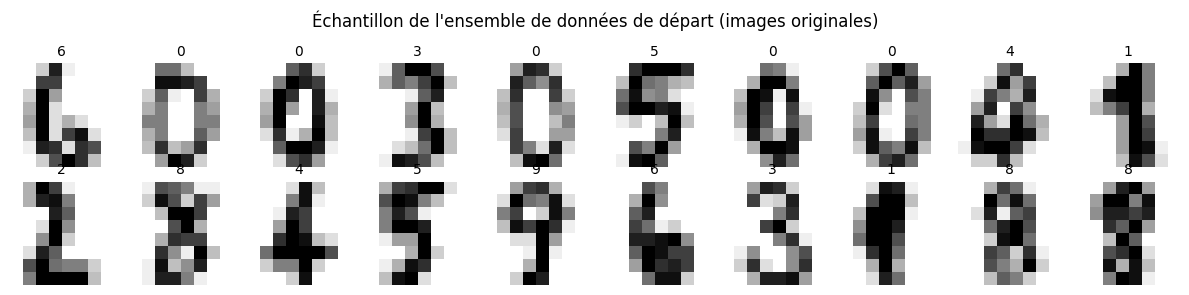

In [23]:
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(str(y_train[i]), fontsize=10)
    ax.axis("off")
plt.suptitle("Échantillon de l'ensemble de données de départ (images originales)")
plt.tight_layout()
plt.show()

## 11. Entraînement des deux auto-encodeurs

- **latent_dim = 2** : pour pouvoir visualiser directement l'espace latent en 2D
- **latent_dim = 32** : pour une meilleure qualité de reconstruction

In [24]:
print("Entraînement latent_dim = 2 ...")
params_2, hist_2 = train_autoencoder(X_train, latent_dim=2, epochs=400)

Entraînement latent_dim = 2 ...
  [latent_dim=2] epoch    0/400  MSE = 0.08536
  [latent_dim=2] epoch   50/400  MSE = 0.04248
  [latent_dim=2] epoch  100/400  MSE = 0.03682
  [latent_dim=2] epoch  150/400  MSE = 0.03372
  [latent_dim=2] epoch  200/400  MSE = 0.03157
  [latent_dim=2] epoch  250/400  MSE = 0.03026
  [latent_dim=2] epoch  300/400  MSE = 0.02935
  [latent_dim=2] epoch  350/400  MSE = 0.02866
  [latent_dim=2] epoch  399/400  MSE = 0.02808


In [25]:
print("Entraînement latent_dim = 32 ...")
params_32, hist_32 = train_autoencoder(X_train, latent_dim=32, epochs=400)

Entraînement latent_dim = 32 ...
  [latent_dim=32] epoch    0/400  MSE = 0.08629
  [latent_dim=32] epoch   50/400  MSE = 0.01068
  [latent_dim=32] epoch  100/400  MSE = 0.00599
  [latent_dim=32] epoch  150/400  MSE = 0.00449
  [latent_dim=32] epoch  200/400  MSE = 0.00391
  [latent_dim=32] epoch  250/400  MSE = 0.00352
  [latent_dim=32] epoch  300/400  MSE = 0.00316
  [latent_dim=32] epoch  350/400  MSE = 0.00303
  [latent_dim=32] epoch  399/400  MSE = 0.00291


## 12. Courbes de perte (convergence)

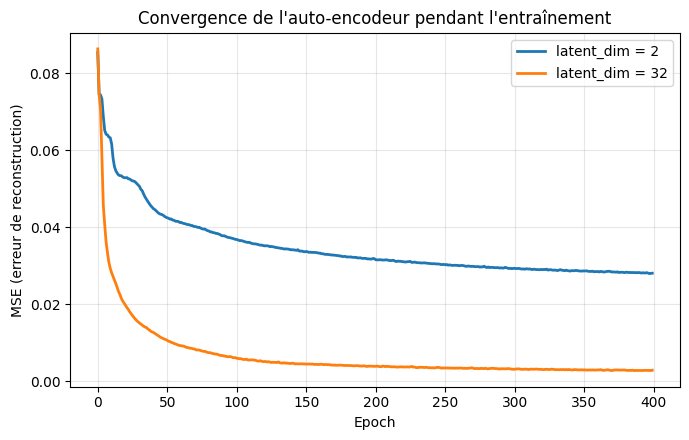

In [26]:
plt.figure(figsize=(7, 4.5))
plt.plot(hist_2, label="latent_dim = 2", linewidth=2)
plt.plot(hist_32, label="latent_dim = 32", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE (erreur de reconstruction)")
plt.title("Convergence de l'auto-encodeur pendant l'entraînement")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Images originales vs reconstruites

On compare, pour les mêmes images du jeu de test :
- la ligne du haut : images **originales**
- les lignes suivantes : reconstructions par `decode(encode(x))`, pour chaque modèle

C'est ici qu'on utilise explicitement `encode()` **puis** `decode()`.

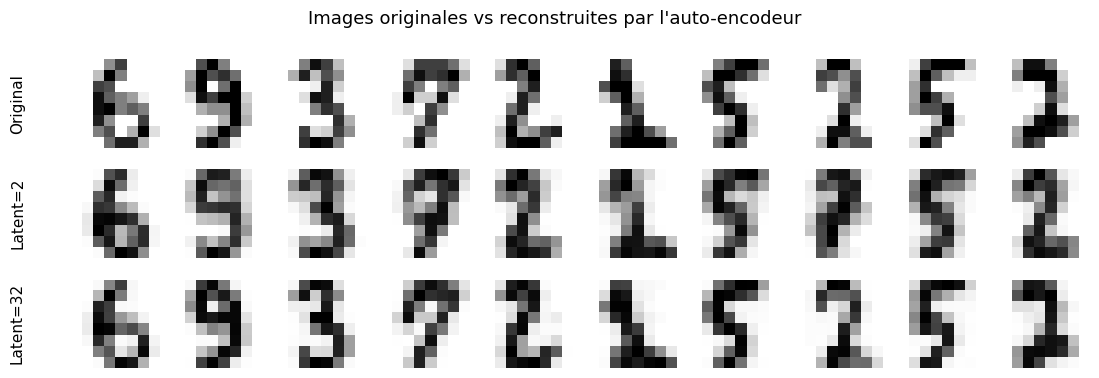

In [27]:
def plot_original_vs_reconstruit(X, params_dict, n_images=10):
    n_rows = 1 + len(params_dict)
    fig, axes = plt.subplots(n_rows, n_images, figsize=(n_images * 1.1, n_rows * 1.3))

    # --- ligne 0 : images ORIGINALES (ensemble de départ) ---
    for i in range(n_images):
        axes[0, i].imshow(X[i].reshape(8, 8), cmap="gray_r")
        axes[0, i].axis("off")
    axes[0, 0].text(-0.6, 0.5, "Original", fontsize=11, rotation=90,
                     va="center", ha="center", transform=axes[0, 0].transAxes)

    # --- lignes suivantes : reconstructions, une par modèle ---
    for row, (nom_modele, params) in enumerate(params_dict.items(), start=1):
        # >>> encode() PUIS decode() <<<
        _, codes = encode(X[:n_images], params)   # compression
        _, X_hat = decode(codes, params)          # RECONSTRUCTION

        for i in range(n_images):
            axes[row, i].imshow(X_hat[i].reshape(8, 8), cmap="gray_r")
            axes[row, i].axis("off")
        axes[row, 0].text(-0.6, 0.5, nom_modele, fontsize=11, rotation=90,
                           va="center", ha="center", transform=axes[row, 0].transAxes)

    plt.suptitle("Images originales vs reconstruites par l'auto-encodeur", fontsize=13)
    plt.tight_layout()
    plt.show()


plot_original_vs_reconstruit(X_test, {"Latent=2": params_2, "Latent=32": params_32}, n_images=10)

## 14. Espace latent 2D

Chaque image du jeu de test est réduite à 2 nombres (`code`). On affiche ces points, colorés par leur vrai label (0 à 9), pour voir si l'auto-encodeur regroupe naturellement les chiffres similaires.

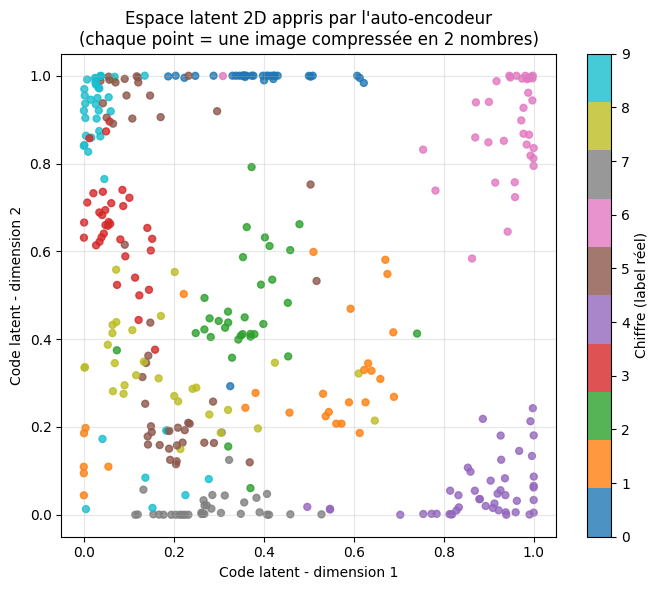

In [28]:
_, codes_test_2d = encode(X_test, params_2)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    codes_test_2d[:, 0], codes_test_2d[:, 1],
    c=y_test, cmap="tab10", s=25, alpha=0.8
)
plt.colorbar(scatter, label="Chiffre (label réel)")
plt.xlabel("Code latent - dimension 1")
plt.ylabel("Code latent - dimension 2")
plt.title("Espace latent 2D appris par l'auto-encodeur\n(chaque point = une image compressée en 2 nombres)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Génération d'images à partir de codes 2D inventés

On démontre ici que `decode()` fonctionne sur **n'importe quel** code, pas seulement ceux issus d'une vraie image : on parcourt une grille régulière de l'espace latent et on décode chaque point.

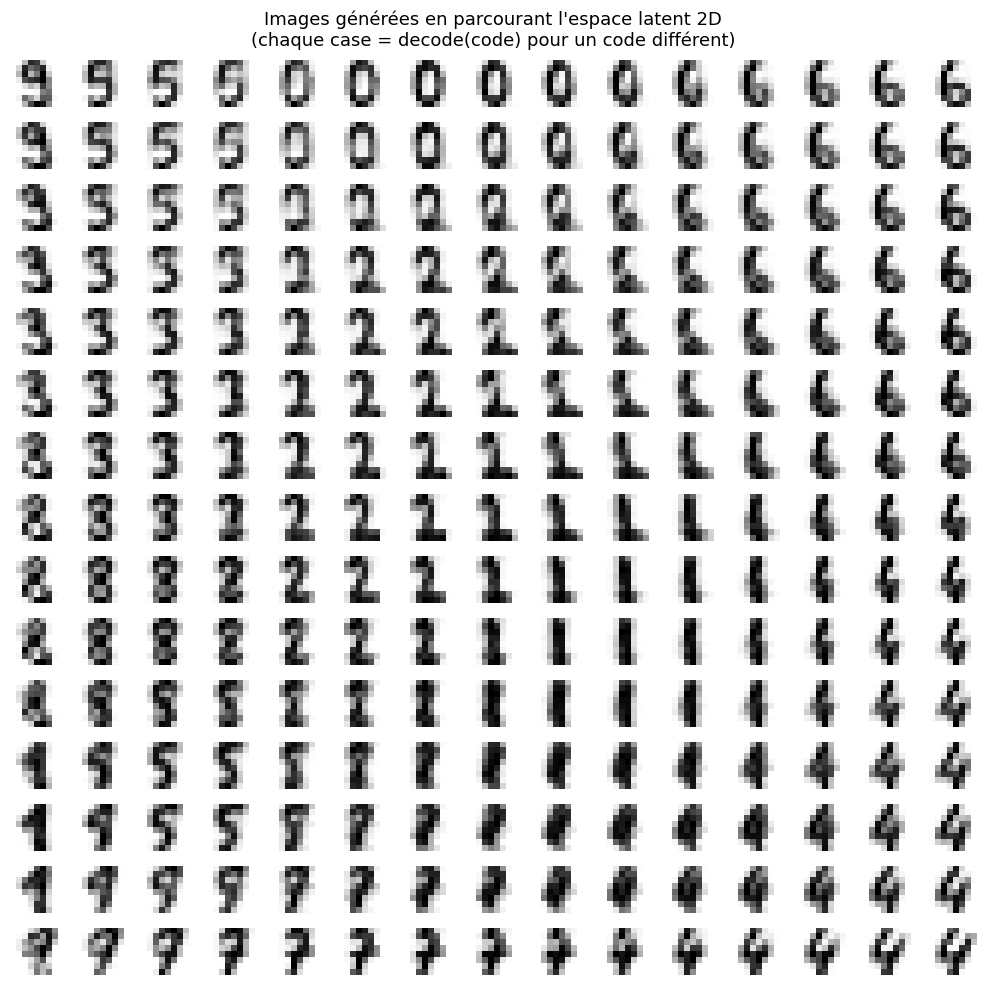

In [29]:
n_grid = 15
u1_min, u1_max = codes_test_2d[:, 0].min(), codes_test_2d[:, 0].max()
u2_min, u2_max = codes_test_2d[:, 1].min(), codes_test_2d[:, 1].max()

grid_u1 = np.linspace(u1_min, u1_max, n_grid)
grid_u2 = np.linspace(u2_min, u2_max, n_grid)

fig, axes = plt.subplots(n_grid, n_grid, figsize=(10, 10))
for i, u2 in enumerate(reversed(grid_u2)):
    for j, u1 in enumerate(grid_u1):
        code_invente = np.array([[u1, u2]])          # code 2D "fabriqué à la main"
        _, image_generee = decode(code_invente, params_2)  # >>> DECODE <<<
        axes[i, j].imshow(image_generee.reshape(8, 8), cmap="gray_r")
        axes[i, j].axis("off")

plt.suptitle("Images générées en parcourant l'espace latent 2D\n(chaque case = decode(code) pour un code différent)", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusion

- L'auto-encodeur apprend à compresser puis reconstruire les données **sans étiquette** (non supervisé)
- Avec `latent_dim=32`, la reconstruction est quasi parfaite (MSE ≈ 0.003)
- Avec `latent_dim=2`, on perd un peu de qualité (MSE ≈ 0.03) mais on peut **visualiser** directement l'espace latent
- La fonction `decode()` peut être appelée sur n'importe quel code, même inventé → possibilité de génération d'images
- Comme dans le cours, avec une seule couche cachée et une fonction sigmoïde, le résultat s'apparente à une ACP non-linéaire

---
# Comparaison de fonctions d'activation : sigmoïde vs tanh vs ReLU

Jusqu'ici, toutes les couches (cachées + sortie) utilisaient la **sigmoïde**. On va maintenant rendre les **couches cachées** configurables (sigmoïde / tanh / ReLU) et comparer.

**Remarque importante** : la couche de **sortie reste toujours en sigmoïde**, car nos pixels sont normalisés entre 0 et 1 — il faut une activation qui produit des valeurs dans cet intervalle pour reconstruire une image valide. Seules les couches cachées (encodeur + décodeur) changent.

| Activation | Plage de sortie | Dérivée | Remarque |
|---|---|---|---|
| Sigmoïde | (0, 1) | `a*(1-a)` | peut saturer (gradients très petits aux extrêmes) |
| Tanh | (-1, 1) | `1 - a²` | centrée sur 0, converge souvent mieux que sigmoïde |
| ReLU | [0, +∞) | `1 si z>0 sinon 0` | pas de saturation côté positif, mais neurones "morts" possibles si z<0 |

In [30]:
# ------------------------------------------------------------------
# Fonctions d'activation + leurs dérivées (calculées à partir de z,
# la pré-activation, pour avoir une interface commune aux 3 cas)
# ------------------------------------------------------------------
def tanh_act(z):
    return np.tanh(z)

def tanh_deriv_from_z(z):
    a = np.tanh(z)
    return 1 - a ** 2

def relu_act(z):
    return np.maximum(0, z)

def relu_deriv_from_z(z):
    return (z > 0).astype(z.dtype)

def sigmoid_deriv_from_z(z):
    a = sigmoid(z)
    return a * (1 - a)

# Dictionnaire : nom -> (fonction d'activation, sa dérivée)
ACTIVATIONS = {
    "sigmoid": (sigmoid, sigmoid_deriv_from_z),
    "tanh":    (tanh_act, tanh_deriv_from_z),
    "relu":    (relu_act, relu_deriv_from_z),
}

### Initialisation adaptée à l'activation

Avec ReLU, l'initialisation de Xavier/Glorot est sous-optimale (elle suppose une activation symétrique autour de 0). On utilise l'initialisation **He** pour ReLU, plus adaptée.

In [31]:
def init_params_v2(input_dim, hidden_dim, latent_dim, activation):
    def glorot(n_in, n_out):
        limite = np.sqrt(6.0 / (n_in + n_out))
        return np.random.uniform(-limite, limite, size=(n_in, n_out))

    def he(n_in, n_out):
        return np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)

    init_fn = he if activation == "relu" else glorot
    return {
        "W1": init_fn(input_dim, hidden_dim),  "b1": np.zeros((1, hidden_dim)),
        "W2": init_fn(hidden_dim, latent_dim), "b2": np.zeros((1, latent_dim)),
        "W3": init_fn(latent_dim, hidden_dim), "b3": np.zeros((1, hidden_dim)),
        "W4": init_fn(hidden_dim, input_dim),  "b4": np.zeros((1, input_dim)),
    }

### `encode()` / `decode()` / `forward()` génériques

Même logique qu'avant, mais on passe maintenant la fonction d'activation en paramètre, et on garde en mémoire les pré-activations (`z1, z2, z3, z4`) en plus des sorties, car ReLU a besoin de `z` (et pas de `a`) pour calculer sa dérivée.

In [32]:
def encode_v2(X, params, act_fn):
    z1 = X @ params["W1"] + params["b1"];  h1 = act_fn(z1)
    z2 = h1 @ params["W2"] + params["b2"]; code = act_fn(z2)
    return z1, h1, z2, code


def decode_v2(code, params, act_fn):
    z3 = code @ params["W3"] + params["b3"]; h2 = act_fn(z3)
    z4 = h2 @ params["W4"] + params["b4"]
    x_hat = sigmoid(z4)   # <-- la sortie reste TOUJOURS en sigmoïde
    return z3, h2, z4, x_hat


def forward_v2(X, params, act_fn):
    z1, h1, z2, code = encode_v2(X, params, act_fn)
    z3, h2, z4, x_hat = decode_v2(code, params, act_fn)
    cache = {"X": X, "z1": z1, "h1": h1, "z2": z2, "code": code,
             "z3": z3, "h2": h2, "z4": z4, "x_hat": x_hat}
    return x_hat, cache

### `backward()` générique

Même structure que précédemment, mais la dérivée utilisée pour les couches cachées dépend maintenant de l'activation choisie. La dernière couche (sortie) garde toujours la dérivée de la sigmoïde.

In [33]:
def backward_v2(params, cache, act_deriv_fn):
    X = cache["X"]
    z1, h1, z2, code = cache["z1"], cache["h1"], cache["z2"], cache["code"]
    z3, h2, z4, x_hat = cache["z3"], cache["h2"], cache["z4"], cache["x_hat"]

    d_xhat = -2.0 * (X - x_hat) / X.size

    # Couche 4 (sortie) : toujours sigmoïde
    d_z4 = d_xhat * sigmoid_deriv_from_z(z4)
    dW4 = h2.T @ d_z4; db4 = d_z4.sum(0, keepdims=True)

    # Couche 3 (décodeur, cachée) : activation choisie
    d_h2 = d_z4 @ params["W4"].T
    d_z3 = d_h2 * act_deriv_fn(z3)
    dW3 = code.T @ d_z3; db3 = d_z3.sum(0, keepdims=True)

    # Couche 2 (encodeur, cachée) : activation choisie
    d_code = d_z3 @ params["W3"].T
    d_z2 = d_code * act_deriv_fn(z2)
    dW2 = h1.T @ d_z2; db2 = d_z2.sum(0, keepdims=True)

    # Couche 1 (encodeur, cachée) : activation choisie
    d_h1 = d_z2 @ params["W2"].T
    d_z1 = d_h1 * act_deriv_fn(z1)
    dW1 = X.T @ d_z1; db1 = d_z1.sum(0, keepdims=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2,
            "W3": dW3, "b3": db3, "W4": dW4, "b4": db4}

### Boucle d'entraînement générique (toutes activations)

In [34]:
def train_v2(X_train, latent_dim, activation, hidden_dim=32,
             epochs=400, batch_size=32, learning_rate=0.01, verbose=True):
    act_fn, act_deriv = ACTIVATIONS[activation]
    n_samples, input_dim = X_train.shape
    params = init_params_v2(input_dim, hidden_dim, latent_dim, activation)
    state = init_adam_state(params)
    loss_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        epoch_losses = []
        for start in range(0, n_samples, batch_size):
            X_batch = X_shuffled[start:start + batch_size]
            x_hat, cache = forward_v2(X_batch, params, act_fn)
            epoch_losses.append(mse_loss(X_batch, x_hat))
            grads = backward_v2(params, cache, act_deriv)
            params = update_params_adam(params, grads, state, learning_rate)
        loss_history.append(np.mean(epoch_losses))
        if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
            print(f"  [{activation:8s}] epoch {epoch:4d}/{epochs}  MSE = {loss_history[-1]:.5f}")

    return params, loss_history

### Entraînement des 3 versions (latent_dim = 32)

On garde `latent_dim=32` pour cette comparaison, afin de juger la qualité de reconstruction sans être trop pénalisé par la compression.

In [35]:
results = {}
for activation in ["sigmoid", "tanh", "relu"]:
    print(f"--- Entraînement avec activation = {activation} ---")
    params, hist = train_v2(X_train, latent_dim=32, activation=activation, epochs=400)
    results[activation] = {"params": params, "history": hist}
    print()

--- Entraînement avec activation = sigmoid ---
  [sigmoid ] epoch    0/400  MSE = 0.08295
  [sigmoid ] epoch  100/400  MSE = 0.00599
  [sigmoid ] epoch  200/400  MSE = 0.00384
  [sigmoid ] epoch  300/400  MSE = 0.00322
  [sigmoid ] epoch  399/400  MSE = 0.00297

--- Entraînement avec activation = tanh ---
  [tanh    ] epoch    0/400  MSE = 0.07818
  [tanh    ] epoch  100/400  MSE = 0.00323
  [tanh    ] epoch  200/400  MSE = 0.00298
  [tanh    ] epoch  300/400  MSE = 0.00279
  [tanh    ] epoch  399/400  MSE = 0.00273

--- Entraînement avec activation = relu ---
  [relu    ] epoch    0/400  MSE = 0.07864
  [relu    ] epoch  100/400  MSE = 0.00715
  [relu    ] epoch  200/400  MSE = 0.00656
  [relu    ] epoch  300/400  MSE = 0.00634
  [relu    ] epoch  399/400  MSE = 0.00605



### Comparaison des courbes de convergence

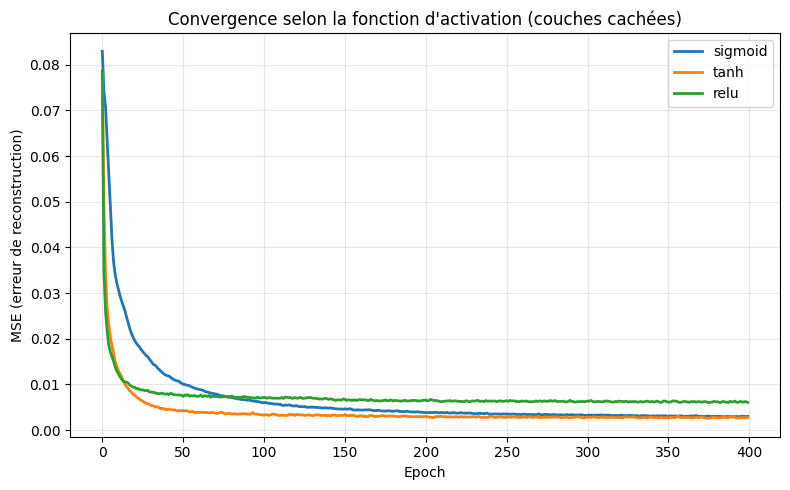

Perte finale (MSE) :
  sigmoid  : 0.00297
  tanh     : 0.00273
  relu     : 0.00605


In [36]:
plt.figure(figsize=(8, 5))
for activation, res in results.items():
    plt.plot(res["history"], label=activation, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE (erreur de reconstruction)")
plt.title("Convergence selon la fonction d'activation (couches cachées)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Perte finale (MSE) :")
for activation, res in results.items():
    print(f"  {activation:8s} : {res['history'][-1]:.5f}")

### Comparaison visuelle des reconstructions

Mêmes images de test, reconstruites par les 3 versions du modèle.

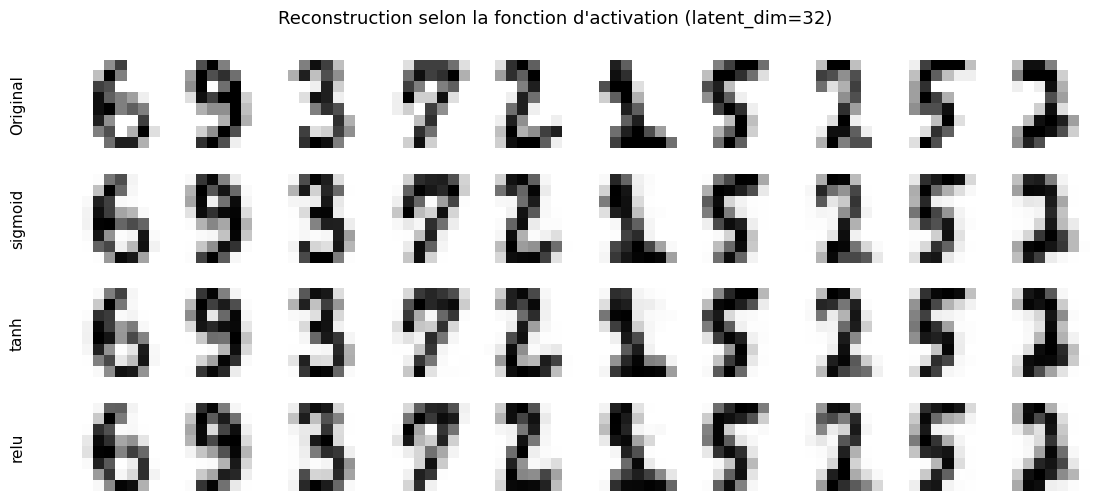

In [37]:
def plot_comparaison_activations(X, results_dict, n_images=10):
    n_rows = 1 + len(results_dict)
    fig, axes = plt.subplots(n_rows, n_images, figsize=(n_images * 1.1, n_rows * 1.3))

    for i in range(n_images):
        axes[0, i].imshow(X[i].reshape(8, 8), cmap="gray_r")
        axes[0, i].axis("off")
    axes[0, 0].text(-0.6, 0.5, "Original", fontsize=11, rotation=90,
                     va="center", ha="center", transform=axes[0, 0].transAxes)

    for row, (activation, res) in enumerate(results_dict.items(), start=1):
        act_fn, _ = ACTIVATIONS[activation]
        params = res["params"]
        _, _, _, codes = encode_v2(X[:n_images], params, act_fn)
        _, _, _, X_hat = decode_v2(codes, params, act_fn)

        for i in range(n_images):
            axes[row, i].imshow(X_hat[i].reshape(8, 8), cmap="gray_r")
            axes[row, i].axis("off")
        axes[row, 0].text(-0.6, 0.5, activation, fontsize=11, rotation=90,
                           va="center", ha="center", transform=axes[row, 0].transAxes)

    plt.suptitle("Reconstruction selon la fonction d'activation (latent_dim=32)", fontsize=13)
    plt.tight_layout()
    plt.show()


plot_comparaison_activations(X_test, results, n_images=10)

### Conclusion sur les activations

- **Sigmoïde** : fonctionne bien mais peut saturer (gradients très faibles quand les valeurs sont proches de 0 ou 1), ce qui ralentit parfois l'apprentissage dans les couches profondes.
- **Tanh** : souvent un peu plus rapide à converger que la sigmoïde, car centrée sur 0 (les gradients ne sont pas systématiquement du même signe, ce qui aide la descente de gradient).
- **ReLU** : pas de saturation côté positif, calcul très rapide, c'est le choix standard en deep learning moderne. Mais elle peut créer des "neurones morts" (si z<0 en permanence, le gradient est nul et le neurone n'apprend plus) — d'où l'utilité d'une initialisation adaptée (He) et d'un learning rate raisonnable.
- Sur ce petit dataset (digits, 64 pixels), les 3 activations donnent des résultats globalement proches — les différences deviennent plus marquées sur des réseaux plus profonds ou des données plus complexes (images couleur haute résolution, etc.).